# Machine Learning Models for FIQA Score Prediction

This notebook evaluates different machine learning approaches for predicting
CR-FIQA scores from facial attributes and demographic information.

The workflow consists of:

1. Loading the merged dataset
2. Defining continuous, binary, and categorical features
3. Preventing identity leakage through a group-based train-test split
4. Preprocessing the different feature types
5. Preparing the data for machine learning models


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from google.colab import drive

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [2]:
# Mount Google Drive
drive.mount("/content/drive")


Mounted at /content/drive


In [3]:
# Define project paths
PROJECT_PATH = Path("/content/drive/MyDrive/FIQA_Project")
DATA_FILE = PROJECT_PATH / "diveface_fiqa_merged.csv"

print("Project path:", PROJECT_PATH)
print("Data file:", DATA_FILE)
print("File exists:", DATA_FILE.exists())


Project path: /content/drive/MyDrive/FIQA_Project
Data file: /content/drive/MyDrive/FIQA_Project/diveface_fiqa_merged.csv
File exists: True


In [4]:
# Load the merged DiveFace and CR-FIQA dataset
df = pd.read_csv(DATA_FILE)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (9311, 23)


,index,age,smile,moustache,beard,sideburns,mask,headWear,glasses,head_roll,...,lip_makeup,forehead_occluded,eye_occluded,mouth_occluded,blur,exposure,noise,group,cls,cr_fiqa_score
0,10217633@N02_identity_32/9153065219_1.jpg,40,0.978,0.4,0.4,0.1,False,False,True,21.5,...,False,False,False,False,0.14,0.52,0.09,Asian Man,10217633@N02_identity_32,1.120962
1,10217633@N02_identity_32/9153127191_0.jpg,36,0.001,0.1,0.1,0.1,False,False,True,6.1,...,False,False,False,False,0.20,0.55,0.00,Asian Man,10217633@N02_identity_32,1.889838
2,10217633@N02_identity_32/9153134725_0.jpg,36,0.012,0.1,0.1,0.1,False,False,True,-3.6,...,False,False,False,False,0.17,0.53,0.05,Asian Man,10217633@N02_identity_32,1.588633
3,10217633@N02_identity_32/9155283282_4.jpg,43,0.009,0.4,0.4,0.1,False,False,True,-3.1,...,False,False,False,False,0.00,0.46,0.00,Asian Man,10217633@N02_identity_32,1.807411
4,10217633@N02_identity_32/9155357580_0.jpg,36,0.002,0.1,0.1,0.1,False,False,True,-3.4,...,False,False,False,False,0.19,0.50,0.26,Asian Man,10217633@N02_identity_32,1.885370


In [5]:
# Display basic dataset information
print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())


Columns:
['index', 'age', 'smile', 'moustache', 'beard', 'sideburns', 'mask', 'headWear', 'glasses', 'head_roll', 'head_yaw', 'head_pitch', 'eye_makeup', 'lip_makeup', 'forehead_occluded', 'eye_occluded', 'mouth_occluded', 'blur', 'exposure', 'noise', 'group', 'cls', 'cr_fiqa_score']

Data types:
index                 object
age                    int64
smile                float64
moustache            float64
beard                float64
sideburns            float64
mask                    bool
headWear                bool
glasses                 bool
head_roll            float64
head_yaw             float64
head_pitch           float64
eye_makeup              bool
lip_makeup              bool
forehead_occluded       bool
eye_occluded            bool
mouth_occluded          bool
blur                 float64
exposure             float64
noise                float64
group                 object
cls                   object
cr_fiqa_score        float64
dtype: object

Missing values:
inde

## Feature Definition

The variables are divided into continuous, binary, and categorical features.

The columns `index` and `cls` are not used as model inputs:

- `index` contains the image path.
- `cls` represents the identity of the person.

Using the identity as a predictor could lead to identity leakage. However,
`cls` is retained temporarily to ensure that images from the same identity
are not distributed across both the training and test sets.


In [6]:
# Define the target variable
target = "cr_fiqa_score"

# Continuous numerical features
continuous_features = [
    "age",
    "smile",
    "moustache",
    "beard",
    "sideburns",
    "head_roll",
    "head_yaw",
    "head_pitch",
    "blur",
    "exposure",
    "noise",
]

# Binary features
binary_features = [
    "mask",
    "headWear",
    "glasses",
    "eye_makeup",
    "lip_makeup",
    "forehead_occluded",
    "eye_occluded",
    "mouth_occluded",
]

# Categorical features
categorical_features = [
    "group",
]

# Columns that must not be used as model input
excluded_features = [
    "index",
    "cls",
]


In [7]:
# Check whether all required columns exist
required_columns = (
    continuous_features
    + binary_features
    + categorical_features
    + excluded_features
    + [target]
)

missing_columns = [
    column
    for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        f"The following required columns are missing: {missing_columns}"
    )

print("All required columns are available.")


All required columns are available.


In [8]:
# Convert Boolean binary features to integers
df[binary_features] = df[binary_features].astype(int)

print("Binary feature values:")
for feature in binary_features:
    print(f"{feature}: {sorted(df[feature].unique())}")


Binary feature values:
mask: [np.int64(0), np.int64(1)]
headWear: [np.int64(0), np.int64(1)]
glasses: [np.int64(0), np.int64(1)]
eye_makeup: [np.int64(0), np.int64(1)]
lip_makeup: [np.int64(0), np.int64(1)]
forehead_occluded: [np.int64(0), np.int64(1)]
eye_occluded: [np.int64(0), np.int64(1)]
mouth_occluded: [np.int64(0), np.int64(1)]


In [9]:
# Check missing values in model-relevant columns
model_columns = (
    continuous_features
    + binary_features
    + categorical_features
    + ["cls", target]
)

missing_values = df[model_columns].isna().sum()
missing_values = missing_values[missing_values > 0]

if missing_values.empty:
    print("No missing values found in the model-relevant columns.")
else:
    print("Missing values found:")
    print(missing_values)


No missing values found in the model-relevant columns.


## Identity-Aware Train-Test Split

A conventional random train-test split could place images of the same person
in both subsets. This may cause the model to indirectly learn
identity-specific patterns and produce overly optimistic evaluation results.

Therefore, the dataset is split based on the `cls` identity column. All images
belonging to one identity are assigned either to the training set or to the
test set.


In [10]:
# Define model features
feature_columns = (
    continuous_features
    + binary_features
    + categorical_features
)

X = df[feature_columns].copy()
y = df[target].copy()

# Identity labels are used only for splitting
groups = df["cls"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Number of identities:", groups.nunique())


Feature matrix shape: (9311, 20)
Target shape: (9311,)
Number of identities: 1702


In [11]:
# Create an identity-aware train-test split
group_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42,
)

train_indices, test_indices = next(
    group_split.split(
        X,
        y,
        groups=groups,
    )
)

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

groups_train = groups.iloc[train_indices]
groups_test = groups.iloc[test_indices]

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("Training identities:", groups_train.nunique())
print("Test identities:", groups_test.nunique())


Training set shape: (7577, 20)
Test set shape: (1734, 20)
Training identities: 1361
Test identities: 341


In [12]:
# Verify that no identity occurs in both subsets
train_identities = set(groups_train.unique())
test_identities = set(groups_test.unique())

overlapping_identities = train_identities.intersection(test_identities)

print("Overlapping identities:", len(overlapping_identities))

assert len(overlapping_identities) == 0, (
    "Identity leakage detected: some identities occur in both datasets."
)

print("No identity leakage detected.")


Overlapping identities: 0
No identity leakage detected.


## Feature Preprocessing

Different preprocessing steps are applied to the feature groups:

- Continuous features are standardized.
- Binary features are passed through without scaling.
- The demographic `group` feature is one-hot encoded.

The preprocessing transformer is fitted only on the training data to prevent
information from the test set from influencing the training process.


In [13]:
# Create preprocessing pipelines for the different feature types
preprocessor = ColumnTransformer(
    transformers=[
        (
            "continuous",
            StandardScaler(),
            continuous_features,
        ),
        (
            "binary",
            "passthrough",
            binary_features,
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
                sparse_output=False,
            ),
            categorical_features,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

preprocessor


ColumnTransformer(transformers=[('continuous', StandardScaler(),
                                 ['age', 'smile', 'moustache', 'beard',
                                  'sideburns', 'head_roll', 'head_yaw',
                                  'head_pitch', 'blur', 'exposure', 'noise']),
                                ('binary', 'passthrough',
                                 ['mask', 'headWear', 'glasses', 'eye_makeup',
                                  'lip_makeup', 'forehead_occluded',
                                  'eye_occluded', 'mouth_occluded']),
                                ('categorical',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 ['group'])],
                  verbose_feature_names_out=False)

In [14]:
# Fit the preprocessor only on the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the fitted transformation to the test data
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)


Processed training shape: (7577, 24)
Processed test shape: (1734, 24)


In [15]:
# Retrieve the final feature names
processed_feature_names = preprocessor.get_feature_names_out()

print("Number of processed features:", len(processed_feature_names))
print("\nProcessed features:")

for feature in processed_feature_names:
    print(feature)


Number of processed features: 24

Processed features:
age
smile
moustache
beard
sideburns
head_roll
head_yaw
head_pitch
blur
exposure
noise
mask
headWear
glasses
eye_makeup
lip_makeup
forehead_occluded
eye_occluded
mouth_occluded
group_Asian Woman
group_Black Man
group_Black Woman
group_Caucasian Man
group_Caucasian Woman


In [16]:
# Convert processed arrays into DataFrames for easier inspection
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=processed_feature_names,
    index=X_train.index,
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=processed_feature_names,
    index=X_test.index,
)

display(X_train_processed_df.head())


,age,smile,moustache,beard,sideburns,head_roll,head_yaw,head_pitch,blur,exposure,...,eye_makeup,lip_makeup,forehead_occluded,eye_occluded,mouth_occluded,group_Asian Woman,group_Black Man,group_Black Woman,group_Caucasian Man,group_Caucasian Woman
0,0.571740,0.743298,1.946755,1.707050,0.400834,2.626988,-0.244793,0.475860,-0.696073,-0.247757,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.216404,-1.497811,0.024190,-0.042407,0.400834,0.749019,-1.651371,0.899733,-0.490485,-0.077448,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.216404,-1.472578,0.024190,-0.042407,0.400834,-0.433857,-1.165377,1.198938,-0.593279,-0.190987,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.838241,-1.479460,1.946755,1.707050,0.400834,-0.372884,-1.791562,0.625462,-1.175777,-0.588373,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.216404,-1.495517,0.024190,-0.042407,0.400834,-0.409468,-1.282203,1.061803,-0.524750,-0.361295,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
# Final summary of the prepared data
print("Original dataset:", df.shape)
print("Original feature matrix:", X.shape)

print("\nTraining data before preprocessing:", X_train.shape)
print("Test data before preprocessing:", X_test.shape)

print("\nTraining data after preprocessing:", X_train_processed_df.shape)
print("Test data after preprocessing:", X_test_processed_df.shape)

print("\nTarget mean:")
print("Training:", round(y_train.mean(), 4))
print("Test:", round(y_test.mean(), 4))

print("\nTarget standard deviation:")
print("Training:", round(y_train.std(), 4))
print("Test:", round(y_test.std(), 4))


Original dataset: (9311, 23)
Original feature matrix: (9311, 20)

Training data before preprocessing: (7577, 20)
Test data before preprocessing: (1734, 20)

Training data after preprocessing: (7577, 24)
Test data after preprocessing: (1734, 24)

Target mean:
Training: 1.6953
Test: 1.702

Target standard deviation:
Training: 0.3421
Test: 0.3335


# Part B – Model Training and Evaluation

In this section, several regression models are trained to predict the
CR-FIQA score.

The following approaches are evaluated:

1. Mean baseline
2. Linear Regression
3. Ridge Regression
4. Random Forest Regression

The models are compared using:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Coefficient of Determination ($R^2$)

A lower MAE and RMSE indicate better predictions, while a higher $R^2$
indicates that the model explains more of the variance in the CR-FIQA scores.

In [18]:
# Imports for model training and evaluation
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [19]:
# Define a reusable evaluation function
def evaluate_regression_model(
    model_name,
    model,
    X_train,
    X_test,
    y_train,
    y_test,
):
    """
    Train and evaluate a regression model.

    Parameters
    ----------
    model_name : str
        Name used in the result table.
    model : sklearn estimator
        Regression model to train.
    X_train, X_test :
        Training and test features.
    y_train, y_test :
        Training and test targets.

    Returns
    -------
    results : dict
        Evaluation metrics for the model.
    predictions : np.ndarray
        Predictions for the test set.
    fitted_model :
        Trained regression model.
    """

    # Train the model
    model.fit(X_train, y_train)

    # Generate predictions
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    # Calculate training metrics
    train_mae = mean_absolute_error(
        y_train,
        train_predictions,
    )

    train_rmse = np.sqrt(
        mean_squared_error(
            y_train,
            train_predictions,
        )
    )

    train_r2 = r2_score(
        y_train,
        train_predictions,
    )

    # Calculate test metrics
    test_mae = mean_absolute_error(
        y_test,
        test_predictions,
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            test_predictions,
        )
    )

    test_r2 = r2_score(
        y_test,
        test_predictions,
    )

    results = {
        "Model": model_name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train R²": train_r2,
        "Test R²": test_r2,
    }

    return results, test_predictions, model

## Mean Baseline

The baseline model always predicts the mean CR-FIQA score observed in the
training data.

A useful machine learning model should perform better than this baseline.

In [20]:
# Create the mean baseline model
baseline_model = DummyRegressor(
    strategy="mean",
)

baseline_results, baseline_predictions, baseline_model = (
    evaluate_regression_model(
        model_name="Mean Baseline",
        model=baseline_model,
        X_train=X_train_processed_df,
        X_test=X_test_processed_df,
        y_train=y_train,
        y_test=y_test,
    )
)

print("Mean Baseline Results:")
for metric, value in baseline_results.items():
    if metric == "Model":
        print(f"{metric}: {value}")
    else:
        print(f"{metric}: {value:.4f}")

Mean Baseline Results:
Model: Mean Baseline
Train MAE: 0.2794
Test MAE: 0.2729
Train RMSE: 0.3420
Test RMSE: 0.3335
Train R²: 0.0000
Test R²: -0.0004


## Linear Regression

Linear Regression serves as an interpretable model for investigating whether
the facial and demographic attributes have approximately linear relationships
with the CR-FIQA score.

In [21]:
# Create and evaluate the Linear Regression model
linear_model = LinearRegression()

linear_results, linear_predictions, linear_model = (
    evaluate_regression_model(
        model_name="Linear Regression",
        model=linear_model,
        X_train=X_train_processed_df,
        X_test=X_test_processed_df,
        y_train=y_train,
        y_test=y_test,
    )
)

print("Linear Regression Results:")
for metric, value in linear_results.items():
    if metric == "Model":
        print(f"{metric}: {value}")
    else:
        print(f"{metric}: {value:.4f}")

Linear Regression Results:
Model: Linear Regression
Train MAE: 0.2721
Test MAE: 0.2688
Train RMSE: 0.3350
Test RMSE: 0.3277
Train R²: 0.0409
Test R²: 0.0342


## Ridge Regression

Ridge Regression extends Linear Regression by adding L2 regularization.
Regularization reduces excessively large coefficients and can improve
generalization when predictor variables are correlated.

In [22]:
# Create and evaluate the Ridge Regression model
ridge_model = Ridge(
    alpha=1.0,
)

ridge_results, ridge_predictions, ridge_model = (
    evaluate_regression_model(
        model_name="Ridge Regression",
        model=ridge_model,
        X_train=X_train_processed_df,
        X_test=X_test_processed_df,
        y_train=y_train,
        y_test=y_test,
    )
)

print("Ridge Regression Results:")
for metric, value in ridge_results.items():
    if metric == "Model":
        print(f"{metric}: {value}")
    else:
        print(f"{metric}: {value:.4f}")

Ridge Regression Results:
Model: Ridge Regression
Train MAE: 0.2721
Test MAE: 0.2687
Train RMSE: 0.3350
Test RMSE: 0.3276
Train R²: 0.0409
Test R²: 0.0348


## Random Forest Regression

Random Forest Regression can model nonlinear relationships and interactions
between features. Unlike Linear Regression, it does not assume that the
relationship between an attribute and the CR-FIQA score is linear.

In [23]:
# Create and evaluate the Random Forest model
random_forest_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

random_forest_results, random_forest_predictions, random_forest_model = (
    evaluate_regression_model(
        model_name="Random Forest",
        model=random_forest_model,
        X_train=X_train_processed_df,
        X_test=X_test_processed_df,
        y_train=y_train,
        y_test=y_test,
    )
)

print("Random Forest Results:")
for metric, value in random_forest_results.items():
    if metric == "Model":
        print(f"{metric}: {value}")
    else:
        print(f"{metric}: {value:.4f}")

Random Forest Results:
Model: Random Forest
Train MAE: 0.1104
Test MAE: 0.2409
Train RMSE: 0.1420
Test RMSE: 0.2946
Train R²: 0.8277
Test R²: 0.2194


## Model Comparison

The trained models are compared using their training and test performance.

A large difference between training and test performance may indicate
overfitting.

In [24]:
# Combine all model results into one table
model_results = pd.DataFrame(
    [
        baseline_results,
        linear_results,
        ridge_results,
        random_forest_results,
    ]
)

# Sort models by test RMSE
model_results = model_results.sort_values(
    by="Test RMSE",
    ascending=True,
).reset_index(drop=True)

display(
    model_results.style.format(
        {
            "Train MAE": "{:.4f}",
            "Test MAE": "{:.4f}",
            "Train RMSE": "{:.4f}",
            "Test RMSE": "{:.4f}",
            "Train R²": "{:.4f}",
            "Test R²": "{:.4f}",
        }
    )
)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
0,Random Forest,0.1104,0.2409,0.1420,0.2946,0.8277,0.2194
1,Ridge Regression,0.2721,0.2687,0.3350,0.3276,0.0409,0.0348
2,Linear Regression,0.2721,0.2688,0.3350,0.3277,0.0409,0.0342
3,Mean Baseline,0.2794,0.2729,0.3420,0.3335,0.0000,-0.0004


In [25]:
# Identify the model with the lowest test RMSE
best_model_name = model_results.iloc[0]["Model"]
best_test_rmse = model_results.iloc[0]["Test RMSE"]
best_test_r2 = model_results.iloc[0]["Test R²"]

print("Best model based on Test RMSE:")
print("Model:", best_model_name)
print("Test RMSE:", round(best_test_rmse, 4))
print("Test R²:", round(best_test_r2, 4))

Best model based on Test RMSE:
Model: Random Forest
Test RMSE: 0.2946
Test R²: 0.2194


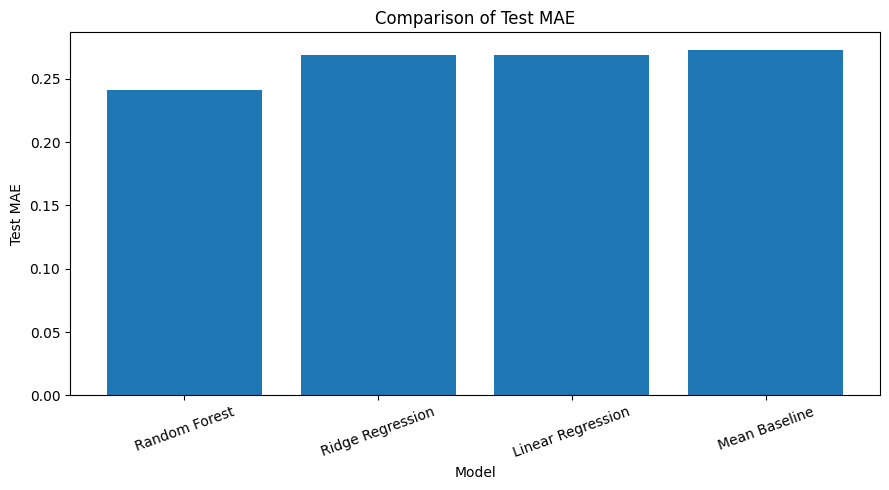

In [26]:
# Compare the test MAE values
plot_results = model_results.sort_values(
    by="Test MAE",
    ascending=True,
)

plt.figure(figsize=(9, 5))

plt.bar(
    plot_results["Model"],
    plot_results["Test MAE"],
)

plt.xlabel("Model")
plt.ylabel("Test MAE")
plt.title("Comparison of Test MAE")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

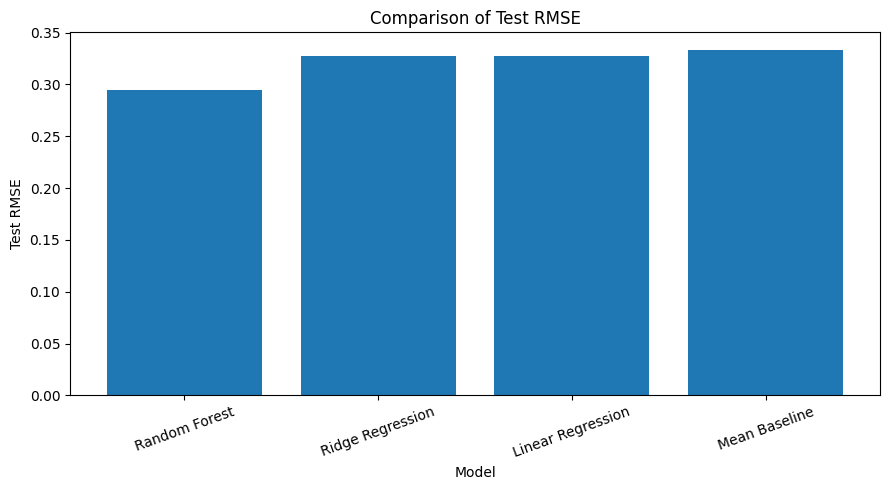

In [27]:
# Compare the test RMSE values
plot_results = model_results.sort_values(
    by="Test RMSE",
    ascending=True,
)

plt.figure(figsize=(9, 5))

plt.bar(
    plot_results["Model"],
    plot_results["Test RMSE"],
)

plt.xlabel("Model")
plt.ylabel("Test RMSE")
plt.title("Comparison of Test RMSE")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

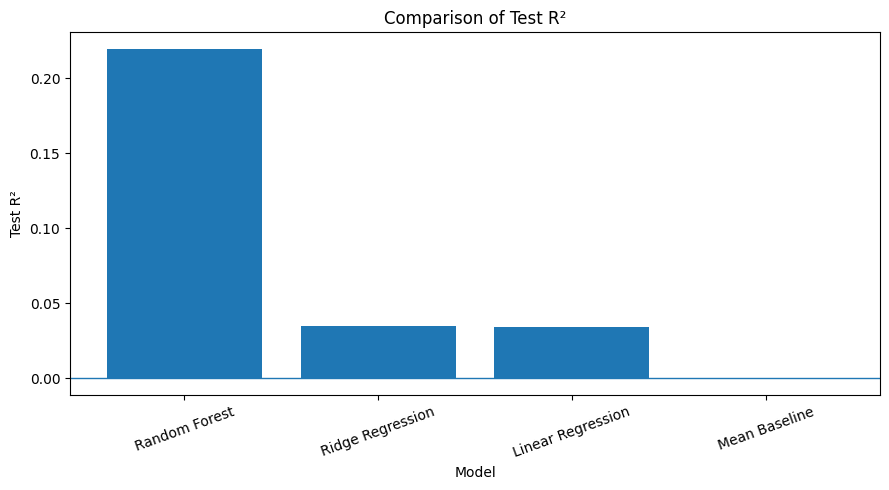

In [28]:
# Compare the test R² values
plot_results = model_results.sort_values(
    by="Test R²",
    ascending=False,
)

plt.figure(figsize=(9, 5))

plt.bar(
    plot_results["Model"],
    plot_results["Test R²"],
)

plt.xlabel("Model")
plt.ylabel("Test R²")
plt.title("Comparison of Test R²")

plt.axhline(
    y=0,
    linewidth=1,
)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [29]:
# Create a DataFrame containing actual and predicted FIQA scores
prediction_results = pd.DataFrame(
    {
        "Actual CR-FIQA Score": y_test,
        "Mean Baseline Prediction": baseline_predictions,
        "Linear Regression Prediction": linear_predictions,
        "Ridge Regression Prediction": ridge_predictions,
        "Random Forest Prediction": random_forest_predictions,
    },
    index=y_test.index,
)

display(prediction_results.head())

,Actual CR-FIQA Score,Mean Baseline Prediction,Linear Regression Prediction,Ridge Regression Prediction,Random Forest Prediction
63,1.891194,1.695292,1.606669,1.606175,1.679067
64,1.445774,1.695292,1.694965,1.694602,1.905655
65,2.170404,1.695292,1.782628,1.782381,1.947876
73,2.183455,1.695292,1.762167,1.761795,1.869536
74,1.707656,1.695292,1.787375,1.787020,1.656933


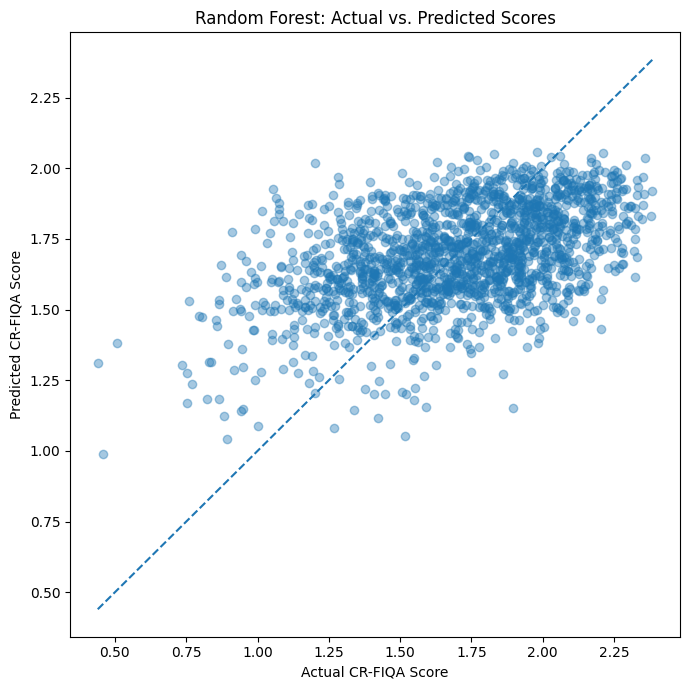

In [30]:
# Plot actual versus predicted scores for the Random Forest model
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    random_forest_predictions,
    alpha=0.4,
)

minimum_value = min(
    y_test.min(),
    random_forest_predictions.min(),
)

maximum_value = max(
    y_test.max(),
    random_forest_predictions.max(),
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
)

plt.xlabel("Actual CR-FIQA Score")
plt.ylabel("Predicted CR-FIQA Score")
plt.title("Random Forest: Actual vs. Predicted Scores")

plt.tight_layout()
plt.show()

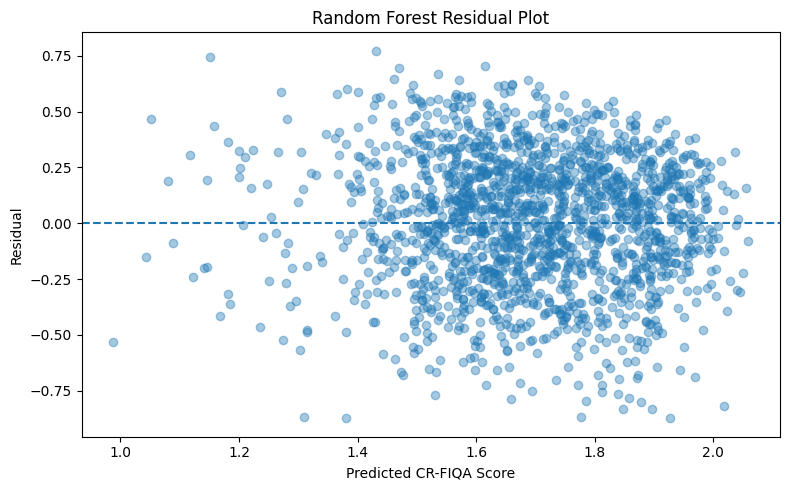

In [31]:
# Calculate residuals
random_forest_residuals = (
    y_test.to_numpy()
    - random_forest_predictions
)

plt.figure(figsize=(8, 5))

plt.scatter(
    random_forest_predictions,
    random_forest_residuals,
    alpha=0.4,
)

plt.axhline(
    y=0,
    linestyle="--",
)

plt.xlabel("Predicted CR-FIQA Score")
plt.ylabel("Residual")
plt.title("Random Forest Residual Plot")

plt.tight_layout()
plt.show()

In [32]:
# Inspect the coefficients of the Linear Regression model
linear_coefficients = pd.DataFrame(
    {
        "Feature": processed_feature_names,
        "Coefficient": linear_model.coef_,
    }
)

linear_coefficients["Absolute Coefficient"] = (
    linear_coefficients["Coefficient"].abs()
)

linear_coefficients = linear_coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False,
).reset_index(drop=True)

display(linear_coefficients)

,Feature,Coefficient,Absolute Coefficient
0,mask,-0.253141,0.253141
1,forehead_occluded,0.204796,0.204796
2,headWear,-0.133819,0.133819
3,glasses,-0.093647,0.093647
4,group_Black Woman,-0.090842,0.090842
5,group_Caucasian Man,-0.074939,0.074939
6,group_Caucasian Woman,-0.053911,0.053911
7,group_Black Man,-0.052400,0.052400
8,group_Asian Woman,-0.048348,0.048348
9,mouth_occluded,-0.044191,0.044191


In [33]:
# Inspect Random Forest feature importances
random_forest_importances = pd.DataFrame(
    {
        "Feature": processed_feature_names,
        "Importance": random_forest_model.feature_importances_,
    }
)

random_forest_importances = random_forest_importances.sort_values(
    by="Importance",
    ascending=False,
).reset_index(drop=True)

display(random_forest_importances)

,Feature,Importance
0,head_yaw,0.244227
1,head_roll,0.191397
2,head_pitch,0.100046
3,exposure,0.095650
4,age,0.088149
5,blur,0.079626
6,noise,0.060223
7,smile,0.053852
8,eye_makeup,0.010687
9,lip_makeup,0.009475


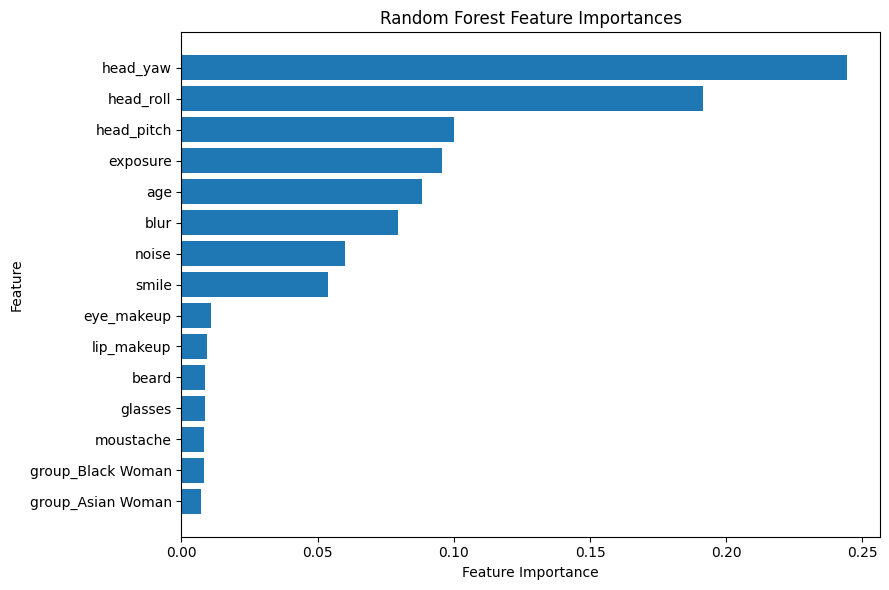

In [34]:
# Plot the most important Random Forest features
top_feature_importances = random_forest_importances.head(15)

plt.figure(figsize=(9, 6))

plt.barh(
    top_feature_importances["Feature"][::-1],
    top_feature_importances["Importance"][::-1],
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importances")

plt.tight_layout()
plt.show()

## Lasso Regression

Lasso Regression extends Linear Regression by adding L1 regularization.

Unlike Ridge Regression, Lasso can reduce some coefficients exactly to zero.
This makes it useful for identifying features that may contribute little to
the prediction of CR-FIQA scores.

In [36]:
from sklearn.linear_model import Lasso
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

In [37]:
# Create and evaluate the Lasso Regression model
lasso_model = Lasso(
    alpha=0.001,
    max_iter=10000,
)

lasso_results, lasso_predictions, lasso_model = (
    evaluate_regression_model(
        model_name="Lasso Regression",
        model=lasso_model,
        X_train=X_train_processed_df,
        X_test=X_test_processed_df,
        y_train=y_train,
        y_test=y_test,
    )
)

print("Lasso Regression Results:")
for metric, value in lasso_results.items():
    if metric == "Model":
        print(f"{metric}: {value}")
    else:
        print(f"{metric}: {value:.4f}")

Lasso Regression Results:
Model: Lasso Regression
Train MAE: 0.2728
Test MAE: 0.2685
Train RMSE: 0.3355
Test RMSE: 0.3272
Train R²: 0.0378
Test R²: 0.0369


In [38]:
# Count coefficients that were reduced to zero
number_of_zero_coefficients = np.sum(
    np.isclose(lasso_model.coef_, 0)
)

print(
    "Number of coefficients reduced to zero:",
    number_of_zero_coefficients,
)

print(
    "Total number of coefficients:",
    len(lasso_model.coef_),
)

Number of coefficients reduced to zero: 6
Total number of coefficients: 24


## Gradient Boosting Regression

Gradient Boosting builds multiple decision trees sequentially.

Each new tree attempts to correct the prediction errors made by the previous
trees. This allows the model to capture nonlinear relationships and feature
interactions.

In [39]:
# Create and evaluate the Gradient Boosting model
gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    loss="squared_error",
    random_state=42,
)

gradient_boosting_results, gradient_boosting_predictions, gradient_boosting_model = (
    evaluate_regression_model(
        model_name="Gradient Boosting",
        model=gradient_boosting_model,
        X_train=X_train_processed_df,
        X_test=X_test_processed_df,
        y_train=y_train,
        y_test=y_test,
    )
)

print("Gradient Boosting Results:")
for metric, value in gradient_boosting_results.items():
    if metric == "Model":
        print(f"{metric}: {value}")
    else:
        print(f"{metric}: {value:.4f}")

Gradient Boosting Results:
Model: Gradient Boosting
Train MAE: 0.2337
Test MAE: 0.2390
Train RMSE: 0.2885
Test RMSE: 0.2932
Train R²: 0.2886
Test R²: 0.2268


## XGBoost Regression

XGBoost is an optimized gradient boosting algorithm that is commonly used for
structured and tabular datasets.

It combines sequential decision trees with regularization and efficient
optimization techniques.

In [40]:
# Create and evaluate the XGBoost model
xgboost_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

xgboost_results, xgboost_predictions, xgboost_model = (
    evaluate_regression_model(
        model_name="XGBoost",
        model=xgboost_model,
        X_train=X_train_processed_df,
        X_test=X_test_processed_df,
        y_train=y_train,
        y_test=y_test,
    )
)

print("XGBoost Results:")
for metric, value in xgboost_results.items():
    if metric == "Model":
        print(f"{metric}: {value}")
    else:
        print(f"{metric}: {value:.4f}")

XGBoost Results:
Model: XGBoost
Train MAE: 0.2147
Test MAE: 0.2379
Train RMSE: 0.2658
Test RMSE: 0.2917
Train R²: 0.3963
Test R²: 0.2346


In [41]:
# Combine all model results into one table
model_results = pd.DataFrame(
    [
        baseline_results,
        linear_results,
        ridge_results,
        lasso_results,
        random_forest_results,
        gradient_boosting_results,
        xgboost_results,
    ]
)

# Sort models by test RMSE
model_results = model_results.sort_values(
    by="Test RMSE",
    ascending=True,
).reset_index(drop=True)

display(
    model_results.style.format(
        {
            "Train MAE": "{:.4f}",
            "Test MAE": "{:.4f}",
            "Train RMSE": "{:.4f}",
            "Test RMSE": "{:.4f}",
            "Train R²": "{:.4f}",
            "Test R²": "{:.4f}",
        }
    )
)

,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
0,XGBoost,0.2147,0.2379,0.2658,0.2917,0.3963,0.2346
1,Gradient Boosting,0.2337,0.2390,0.2885,0.2932,0.2886,0.2268
2,Random Forest,0.1104,0.2409,0.1420,0.2946,0.8277,0.2194
3,Lasso Regression,0.2728,0.2685,0.3355,0.3272,0.0378,0.0369
4,Ridge Regression,0.2721,0.2687,0.3350,0.3276,0.0409,0.0348
5,Linear Regression,0.2721,0.2688,0.3350,0.3277,0.0409,0.0342
6,Mean Baseline,0.2794,0.2729,0.3420,0.3335,0.0000,-0.0004


In [42]:
# Identify the model with the lowest test RMSE
best_model_name = model_results.iloc[0]["Model"]
best_test_rmse = model_results.iloc[0]["Test RMSE"]
best_test_r2 = model_results.iloc[0]["Test R²"]

print("Best model based on Test RMSE:")
print("Model:", best_model_name)
print("Test RMSE:", round(best_test_rmse, 4))
print("Test R²:", round(best_test_r2, 4))

Best model based on Test RMSE:
Model: XGBoost
Test RMSE: 0.2917
Test R²: 0.2346


In [43]:
# Create a DataFrame containing actual and predicted FIQA scores
prediction_results = pd.DataFrame(
    {
        "Actual CR-FIQA Score": y_test,
        "Mean Baseline Prediction": baseline_predictions,
        "Linear Regression Prediction": linear_predictions,
        "Ridge Regression Prediction": ridge_predictions,
        "Lasso Regression Prediction": lasso_predictions,
        "Random Forest Prediction": random_forest_predictions,
        "Gradient Boosting Prediction": gradient_boosting_predictions,
        "XGBoost Prediction": xgboost_predictions,
    },
    index=y_test.index,
)

display(prediction_results.head())

,Actual CR-FIQA Score,Mean Baseline Prediction,Linear Regression Prediction,Ridge Regression Prediction,Lasso Regression Prediction,Random Forest Prediction,Gradient Boosting Prediction,XGBoost Prediction
63,1.891194,1.695292,1.606669,1.606175,1.584356,1.679067,1.742847,1.775514
64,1.445774,1.695292,1.694965,1.694602,1.663812,1.905655,1.870502,1.918350
65,2.170404,1.695292,1.782628,1.782381,1.746899,1.947876,1.929471,1.963522
73,2.183455,1.695292,1.762167,1.761795,1.728558,1.869536,1.738957,1.814103
74,1.707656,1.695292,1.787375,1.787020,1.753017,1.656933,1.618044,1.626124


# Saving Results and Trained Models

The evaluation results, predictions, model interpretation data, preprocessing
transformer, and trained models are saved so that they can be reused in later
notebooks without retraining all models.

In [44]:
from pathlib import Path
import joblib

# Define output directories
RESULTS_PATH = PROJECT_PATH / "results"
MODELS_PATH = PROJECT_PATH / "models"

RESULTS_PATH.mkdir(parents=True, exist_ok=True)
MODELS_PATH.mkdir(parents=True, exist_ok=True)

print("Results directory:", RESULTS_PATH)
print("Models directory:", MODELS_PATH)

Results directory: /content/drive/MyDrive/FIQA_Project/results
Models directory: /content/drive/MyDrive/FIQA_Project/models


In [45]:
# Save the model comparison table
model_comparison_file = RESULTS_PATH / "model_comparison.csv"

model_results.to_csv(
    model_comparison_file,
    index=False,
)

print("Saved:", model_comparison_file)

Saved: /content/drive/MyDrive/FIQA_Project/results/model_comparison.csv


In [46]:
# Create a table with actual scores and predictions from all models
prediction_results = pd.DataFrame(
    {
        "dataset_index": y_test.index,
        "actual_cr_fiqa_score": y_test.to_numpy(),
        "mean_baseline_prediction": baseline_predictions,
        "linear_regression_prediction": linear_predictions,
        "ridge_regression_prediction": ridge_predictions,
        "lasso_regression_prediction": lasso_predictions,
        "random_forest_prediction": random_forest_predictions,
        "gradient_boosting_prediction": gradient_boosting_predictions,
        "xgboost_prediction": xgboost_predictions,
    }
)

display(prediction_results.head())

,dataset_index,actual_cr_fiqa_score,mean_baseline_prediction,linear_regression_prediction,ridge_regression_prediction,lasso_regression_prediction,random_forest_prediction,gradient_boosting_prediction,xgboost_prediction
0,63,1.891194,1.695292,1.606669,1.606175,1.584356,1.679067,1.742847,1.775514
1,64,1.445774,1.695292,1.694965,1.694602,1.663812,1.905655,1.870502,1.918350
2,65,2.170404,1.695292,1.782628,1.782381,1.746899,1.947876,1.929471,1.963522
3,73,2.183455,1.695292,1.762167,1.761795,1.728558,1.869536,1.738957,1.814103
4,74,1.707656,1.695292,1.787375,1.787020,1.753017,1.656933,1.618044,1.626124


In [47]:
# Save all test-set predictions
predictions_file = RESULTS_PATH / "model_predictions.csv"

prediction_results.to_csv(
    predictions_file,
    index=False,
)

print("Saved:", predictions_file)

Saved: /content/drive/MyDrive/FIQA_Project/results/model_predictions.csv


In [48]:
# Add relevant metadata for later model interpretation and group-wise analysis
test_metadata = df.loc[
    y_test.index,
    [
        "index",
        "cls",
        "group",
    ],
].copy()

test_metadata = test_metadata.reset_index().rename(
    columns={
        "index": "dataset_index",
    }
)

# Rename the original image-path column because reset_index creates
# another column called dataset_index
test_metadata = test_metadata.rename(
    columns={
        "dataset_index": "row_index",
        "index": "image_path",
    }
)

display(test_metadata.head())

,level_0,row_index,cls,group
0,63,14323356@N00_identity_1/873689813_0.jpg,14323356@N00_identity_1,Asian Man
1,64,14323356@N00_identity_1/874533856_1.jpg,14323356@N00_identity_1,Asian Man
2,65,14323356@N00_identity_1/874535880_1.jpg,14323356@N00_identity_1,Asian Man
3,73,20183170@N00_identity_15/1344286107_2.jpg,20183170@N00_identity_15,Asian Man
4,74,20183170@N00_identity_15/1345180658_0.jpg,20183170@N00_identity_15,Asian Man


In [52]:
# Save Linear Regression coefficients
linear_coefficients_file = (
    RESULTS_PATH / "linear_regression_coefficients.csv"
)

linear_coefficients.to_csv(
    linear_coefficients_file,
    index=False,
)

print("Saved:", linear_coefficients_file)

Saved: /content/drive/MyDrive/FIQA_Project/results/linear_regression_coefficients.csv


In [53]:
# Create and save Lasso coefficients
lasso_coefficients = pd.DataFrame(
    {
        "Feature": processed_feature_names,
        "Coefficient": lasso_model.coef_,
    }
)

lasso_coefficients["Absolute Coefficient"] = (
    lasso_coefficients["Coefficient"].abs()
)

lasso_coefficients["Is Zero"] = np.isclose(
    lasso_coefficients["Coefficient"],
    0,
)

lasso_coefficients = lasso_coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False,
).reset_index(drop=True)

lasso_coefficients_file = (
    RESULTS_PATH / "lasso_regression_coefficients.csv"
)

lasso_coefficients.to_csv(
    lasso_coefficients_file,
    index=False,
)

print("Saved:", lasso_coefficients_file)

Saved: /content/drive/MyDrive/FIQA_Project/results/lasso_regression_coefficients.csv


In [54]:
def create_feature_importance_table(
    model,
    feature_names,
):
    """
    Create a sorted feature importance table for a fitted tree-based model.
    """

    importance_table = pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": model.feature_importances_,
        }
    )

    return importance_table.sort_values(
        by="Importance",
        ascending=False,
    ).reset_index(drop=True)

In [55]:
# Create Random Forest feature importance table
random_forest_importances = create_feature_importance_table(
    model=random_forest_model,
    feature_names=processed_feature_names,
)

display(random_forest_importances.head(10))

,Feature,Importance
0,head_yaw,0.244227
1,head_roll,0.191397
2,head_pitch,0.100046
3,exposure,0.095650
4,age,0.088149
5,blur,0.079626
6,noise,0.060223
7,smile,0.053852
8,eye_makeup,0.010687
9,lip_makeup,0.009475


In [56]:
# Create Gradient Boosting feature importance table
gradient_boosting_importances = create_feature_importance_table(
    model=gradient_boosting_model,
    feature_names=processed_feature_names,
)

display(gradient_boosting_importances.head(10))

,Feature,Importance
0,head_yaw,0.464196
1,head_roll,0.308001
2,exposure,0.063941
3,age,0.031378
4,blur,0.025116
5,head_pitch,0.023053
6,smile,0.017201
7,glasses,0.012621
8,noise,0.009612
9,eye_makeup,0.009468


In [57]:
# Create XGBoost feature importance table
xgboost_importances = create_feature_importance_table(
    model=xgboost_model,
    feature_names=processed_feature_names,
)

display(xgboost_importances.head(10))

,Feature,Importance
0,head_yaw,0.145961
1,head_roll,0.094447
2,glasses,0.056677
3,group_Black Woman,0.051237
4,exposure,0.048816
5,eye_makeup,0.047994
6,group_Caucasian Man,0.040605
7,smile,0.039226
8,blur,0.038626
9,age,0.038317


In [58]:
# Save tree-based feature importance tables
random_forest_importances_file = (
    RESULTS_PATH / "random_forest_feature_importances.csv"
)

gradient_boosting_importances_file = (
    RESULTS_PATH / "gradient_boosting_feature_importances.csv"
)

xgboost_importances_file = (
    RESULTS_PATH / "xgboost_feature_importances.csv"
)

random_forest_importances.to_csv(
    random_forest_importances_file,
    index=False,
)

gradient_boosting_importances.to_csv(
    gradient_boosting_importances_file,
    index=False,
)

xgboost_importances.to_csv(
    xgboost_importances_file,
    index=False,
)

print("Saved:", random_forest_importances_file)
print("Saved:", gradient_boosting_importances_file)
print("Saved:", xgboost_importances_file)

Saved: /content/drive/MyDrive/FIQA_Project/results/random_forest_feature_importances.csv
Saved: /content/drive/MyDrive/FIQA_Project/results/gradient_boosting_feature_importances.csv
Saved: /content/drive/MyDrive/FIQA_Project/results/xgboost_feature_importances.csv


In [59]:
# Save the final processed feature names
processed_features_file = (
    RESULTS_PATH / "processed_feature_names.csv"
)

pd.DataFrame(
    {
        "Feature": processed_feature_names,
    }
).to_csv(
    processed_features_file,
    index=False,
)

print("Saved:", processed_features_file)

Saved: /content/drive/MyDrive/FIQA_Project/results/processed_feature_names.csv


In [60]:
# Save all trained models
models_to_save = {
    "mean_baseline.joblib": baseline_model,
    "linear_regression.joblib": linear_model,
    "ridge_regression.joblib": ridge_model,
    "lasso_regression.joblib": lasso_model,
    "random_forest.joblib": random_forest_model,
    "gradient_boosting.joblib": gradient_boosting_model,
    "xgboost.joblib": xgboost_model,
}

for filename, model in models_to_save.items():
    model_file = MODELS_PATH / filename
    joblib.dump(model, model_file)
    print("Saved:", model_file)

Saved: /content/drive/MyDrive/FIQA_Project/models/mean_baseline.joblib
Saved: /content/drive/MyDrive/FIQA_Project/models/linear_regression.joblib
Saved: /content/drive/MyDrive/FIQA_Project/models/ridge_regression.joblib
Saved: /content/drive/MyDrive/FIQA_Project/models/lasso_regression.joblib
Saved: /content/drive/MyDrive/FIQA_Project/models/random_forest.joblib
Saved: /content/drive/MyDrive/FIQA_Project/models/gradient_boosting.joblib
Saved: /content/drive/MyDrive/FIQA_Project/models/xgboost.joblib


In [61]:
# Save the fitted preprocessing transformer
preprocessor_file = MODELS_PATH / "preprocessor.joblib"

joblib.dump(
    preprocessor,
    preprocessor_file,
)

print("Saved:", preprocessor_file)

Saved: /content/drive/MyDrive/FIQA_Project/models/preprocessor.joblib


In [62]:
# Save train and test indices for reproducibility
split_information = pd.DataFrame(
    {
        "dataset_index": df.index,
        "split": np.where(
            df.index.isin(y_test.index),
            "test",
            "train",
        ),
        "identity": df["cls"],
        "group": df["group"],
    }
)

split_file = RESULTS_PATH / "train_test_split.csv"

split_information.to_csv(
    split_file,
    index=False,
)

print("Saved:", split_file)

Saved: /content/drive/MyDrive/FIQA_Project/results/train_test_split.csv


In [63]:
# Display saved result files
print("Saved result files:")

for file_path in sorted(RESULTS_PATH.iterdir()):
    print("-", file_path.name)

print("\nSaved model files:")

for file_path in sorted(MODELS_PATH.iterdir()):
    print("-", file_path.name)

Saved result files:
- gradient_boosting_feature_importances.csv
- lasso_regression_coefficients.csv
- linear_regression_coefficients.csv
- model_comparison.csv
- model_predictions.csv
- processed_feature_names.csv
- random_forest_feature_importances.csv
- train_test_split.csv
- xgboost_feature_importances.csv

Saved model files:
- gradient_boosting.joblib
- lasso_regression.joblib
- linear_regression.joblib
- mean_baseline.joblib
- preprocessor.joblib
- random_forest.joblib
- ridge_regression.joblib
- xgboost.joblib
